# SVM

### Data Preparation 


In [1]:
import pandas as pd

# Load the digits dataset
data = pd.read_csv('data/domestic_violence_fake_data.csv')
data

,Age,Exchange_Sex,Children,Suicide_Attempt,Jail,Male,LGBQ,White,Literal_Homeless,Weapon,Gang,PTSD,Depressed,Community_Violence,Sexual_Abuse,Physical_Abuse,Hard_Drug_Use,Foster_Care,Job,Victim
0,67,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0
1,73,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0
2,53,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0
3,79,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,70,1,1,0,0,1,0,1,0,1,0,1,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25,1,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0
9996,85,1,0,0,0,1,0,1,0,0,0,1,1,1,0,0,1,1,0,0
9997,40,1,3,0,1,0,0,0,1,0,0,0,1,1,0,1,0,1,1,0
9998,65,1,1,0,1,0,0,1,0,1,1,0,0,0,0,1,1,1,1,0


## Data Preparation


Treinaremos com 7000 elementos e testaremos com 3000 elementos
A acurácia foi 70.87%
O F1 Score foi 0.67
Matriz de Confusão:
 [[1859  159]
 [ 715  267]]


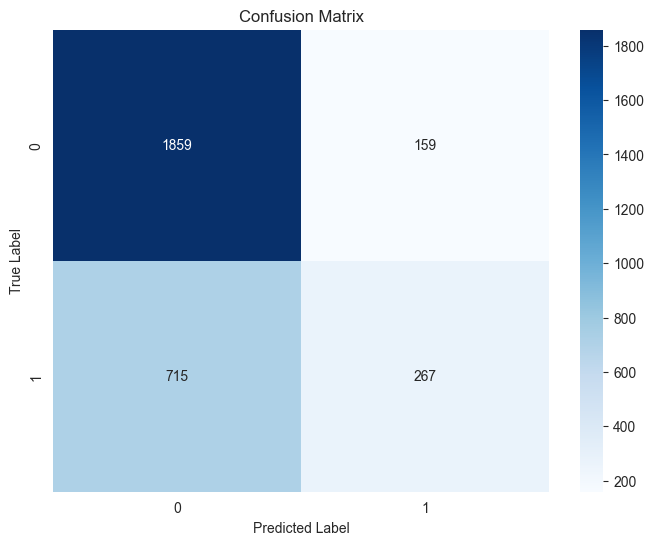

In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split the data into features and target label Age
x = data[["Age", "Exchange_Sex", "Children", "Suicide_Attempt", "Jail", "Male", "LGBQ", "White", "Literal_Homeless", "Weapon","Gang", "PTSD", "Depressed", "Community_Violence", "Sexual_Abuse", "Hard_Drug_Use", "Foster_Care", "Job"]]
y = data["Victim"]

# Split the data (keeping a high test size for demonstration purposes)
raw_train_x, raw_test_x, train_y, test_y = train_test_split(x, y, test_size=0.30, stratify=y)

# Scale the data
scaler = StandardScaler()
scaler.fit(raw_train_x)
train_x = scaler.transform(raw_train_x)
test_x = scaler.transform(raw_test_x)

# Train the model
modelo = SVC()
modelo.fit(train_x, train_y)

# Make predictions
prevision = modelo.predict(test_x)
print("Treinaremos com %d elementos e testaremos com %d elementos" % (len(train_x), len(test_x)))

# Calculate accuracy
accuracy_value = accuracy_score(test_y, prevision) * 100
print("A acurácia foi %.2f%%" % accuracy_value)

# Calculate F1 score
f1_value = f1_score(test_y, prevision, average="weighted")  # Use 'weighted' for imbalanced classes
print("O F1 Score foi %.2f" % f1_value)

# Generate confusion matrix
conf_matrix = confusion_matrix(test_y, prevision)
print("Matriz de Confusão:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


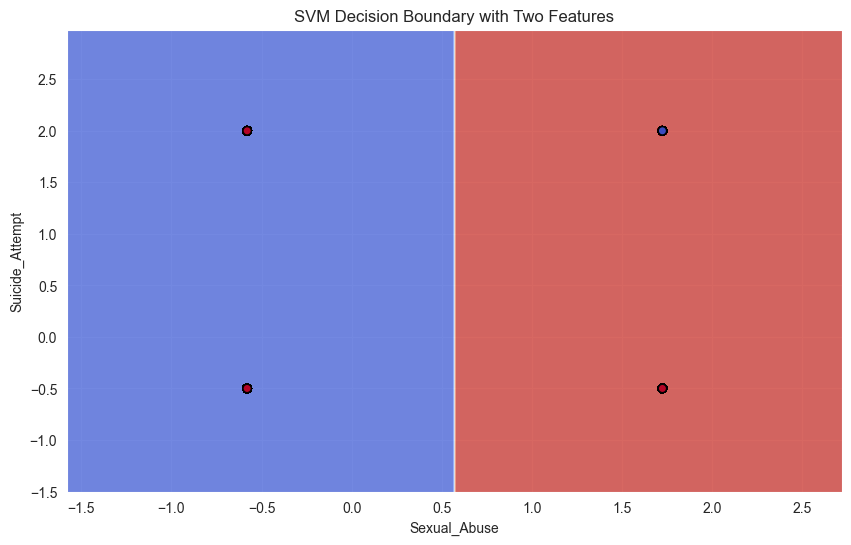

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Use only two features for visualization
x = data[["Sexual_Abuse", "Suicide_Attempt"]]
y = data["Victim"]

# Split the data
raw_train_x, raw_test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, stratify=y)

# Scale the data
scaler = StandardScaler()
scaler.fit(raw_train_x)
train_x = scaler.transform(raw_train_x)
test_x = scaler.transform(raw_test_x)

# Train the SVM model
modelo = SVC(kernel='linear')  # Using a linear kernel for simplicity
modelo.fit(train_x, train_y)

# Create a meshgrid for plotting
h = 0.02
x_min, x_max = test_x[:, 0].min() - 1, test_x[:, 0].max() + 1
y_min, y_max = test_x[:, 1].min() - 1, test_x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on the meshgrid
Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(test_x[:, 0], test_x[:, 1], c=test_y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM Decision Boundary with Two Features")
plt.xlabel("Sexual_Abuse")
plt.ylabel("Suicide_Attempt")
plt.show()


## Test with a dummy classifier

In [4]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
dummy.fit(train_x, train_y)
accuracy = dummy.score(test_x, test_y) * 100
print(f"The accuracy was {accuracy:.2f}%")

The accuracy was 67.25%
